In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os


In [10]:

# ============================================================================
# CONFIGURATION
# ============================================================================
RESULTS_DIR = "DM_distribution_new"
ALPHA_TO_COMPARE = -2

SAVE_PLOT = False

# List of telescopes to look for
TELESCOPES = [
    "fast", 
    "parkes", 
    "meerkat_coherent", 
    "meerkat_incoherent", 
    "askap_flyeye", 
    "askap_ics",
    "dsa-110",
    "apertif"
  
]

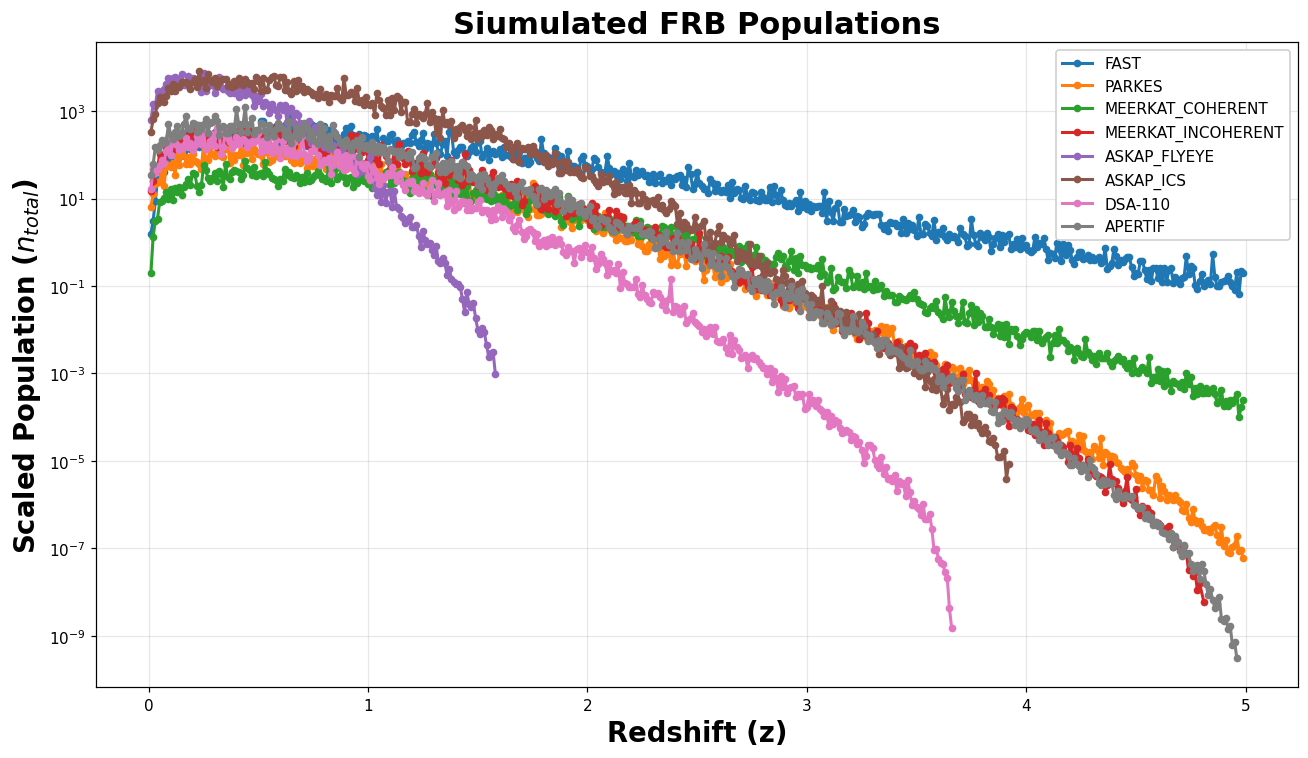


Completed comparison for 8 telescopes.


In [20]:


# ============================================================================
# LOAD AND PLOT
# ============================================================================
plt.figure(figsize=(12, 7), dpi=110)

found_files = 0
for telescope in TELESCOPES:
    # Construct filename based on telescope and alpha
    filename = f"DM_{telescope}_alpha{ALPHA_TO_COMPARE}_scaled.csv"
    filepath = os.path.join(RESULTS_DIR, filename)
    
    if os.path.exists(filepath):
        df = pd.read_csv(filepath)
        
        # Plot Scaled Population vs Redshift
        plt.plot(df['z'], df['n_total_population_scaled'], 
                 marker='o', markersize=4, linewidth=2, label=telescope.upper())
        found_files += 1
    else:
        print(f"File not found: {filename}")

if found_files == 0:
    print(f"No results found for alpha={ALPHA_TO_COMPARE} in {RESULTS_DIR}")
else:
    # Formatting
    # plt.title(f'Siumulated FRB Populations (α = {ALPHA_TO_COMPARE})', 
    #           fontsize=20, fontweight='bold')
    plt.title(f'Siumulated FRB Populations' , 
              fontsize=20, fontweight='bold')
    plt.xlabel('Redshift (z)', fontsize=18, fontweight='bold')
    plt.ylabel('Scaled Population ($n_{total}$)', fontsize=18, fontweight='bold')
    
    # Use log scale for Y if the population range is very large
    plt.yscale('log')
    
    plt.grid(True, which="both", ls="-", alpha=0.3)
    plt.legend(frameon=True, facecolor='white', framealpha=1)
    
    plt.tight_layout()
    
    if SAVE_PLOT:
        plt.savefig(f"population_comparison_alpha{ALPHA_TO_COMPARE}.png")
    
    plt.show()

print(f"\nCompleted comparison for {found_files} telescopes.")

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ============================================================================
# CONFIGURATION
# ============================================================================
RESULTS_DIR = "DM_distribution_new"

# Target redshifts to compare
TARGET_REDSHIFTS = [0.1, 0.3, 0.5, 1.0, 2.0, 4.0]

# List of telescopes to look for
TELESCOPES = [
    "fast", 
    "parkes", 
    "meerkat_coherent", 
    "meerkat_incoherent", 
    "askap_flyeye", 
    "askap_ics",
    "dsa-110",
    "apertif",  # Add this line
]


# ============================================================================
# LOAD DATA FOR ALL TELESCOPES
# ============================================================================
data_dict = {}
for telescope in TELESCOPES:
    filename = f"DM_{telescope}_alpha{ALPHA_TO_COMPARE}_scaled.csv"
    filepath = os.path.join(RESULTS_DIR, filename)
    
    if os.path.exists(filepath):
        df = pd.read_csv(filepath)
        data_dict[telescope] = df
        print(f"✓ Loaded {telescope}")
    else:
        print(f"✗ Not found: {filename}")


✓ Loaded fast
✓ Loaded parkes
✓ Loaded meerkat_coherent
✓ Loaded meerkat_incoherent
✓ Loaded askap_flyeye
✓ Loaded askap_ics
✓ Loaded dsa-110
✓ Loaded apertif


fast                : DM range [   10.0,  4990.0] pc/cm³ | Total pop:    43590.9
parkes              : DM range [   10.0,  4990.0] pc/cm³ | Total pop:    10383.1
meerkat_coherent    : DM range [   10.0,  4990.0] pc/cm³ | Total pop:     4688.8
meerkat_incoherent  : DM range [   10.0,  4810.0] pc/cm³ | Total pop:    25162.5
askap_flyeye        : DM range [   10.0,  1580.0] pc/cm³ | Total pop:   212803.8
askap_ics           : DM range [   10.0,  3920.0] pc/cm³ | Total pop:   411378.7
dsa-110             : DM range [   10.0,  3660.0] pc/cm³ | Total pop:    15665.1
apertif             : DM range [   10.0,  4960.0] pc/cm³ | Total pop:    41098.2


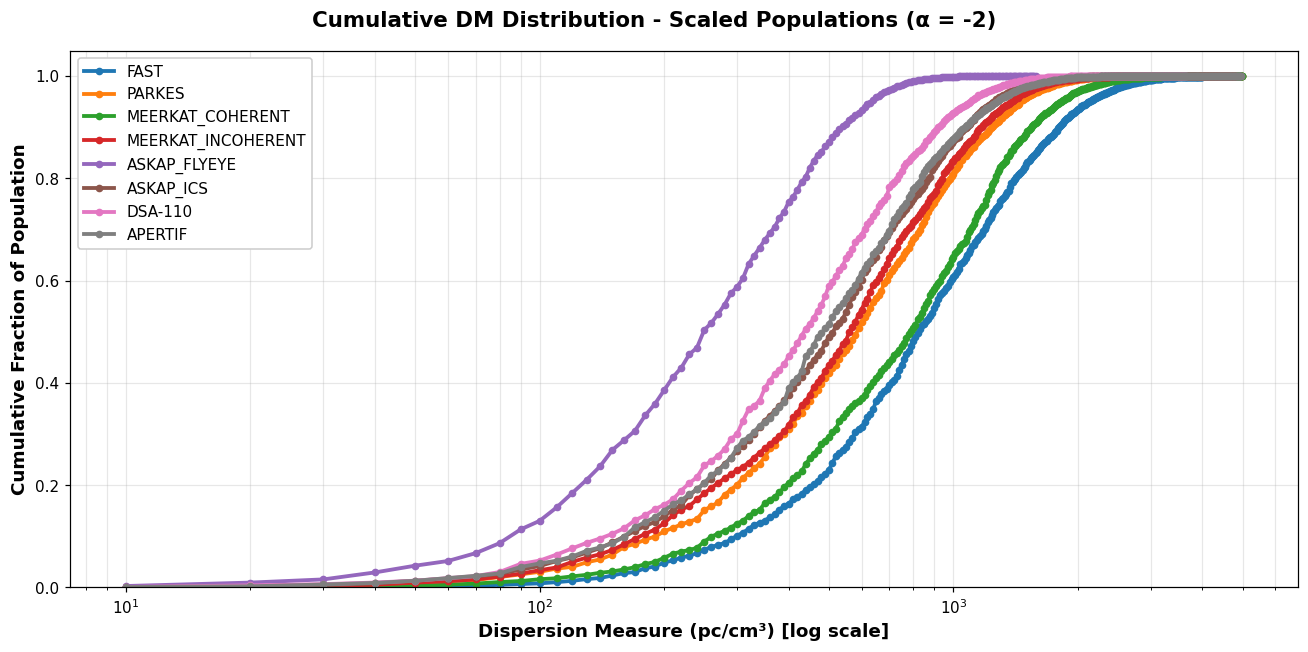


DM STATISTICS SUMMARY
         Telescope  N_Bins DM_min DM_max Total_Population
              FAST     499   10.0 4990.0          43590.9
            PARKES     499   10.0 4990.0          10383.1
  MEERKAT_COHERENT     499   10.0 4990.0           4688.8
MEERKAT_INCOHERENT     480   10.0 4810.0          25162.5
      ASKAP_FLYEYE     158   10.0 1580.0         212803.8
         ASKAP_ICS     392   10.0 3920.0         411378.7
           DSA-110     366   10.0 3660.0          15665.1
           APERTIF     496   10.0 4960.0          41098.2


In [13]:
# ============================================================================
# CUMULATIVE DM DISTRIBUTION FROM SCALED POPULATIONS
# ============================================================================

# ============================================================================
# LOAD DATA FOR ALL TELESCOPES (if not already loaded)
# ============================================================================
if 'data_dict' not in locals():
    data_dict = {}
    for telescope in TELESCOPES:
        filename = f"DM_{telescope}_alpha{ALPHA_TO_COMPARE}_scaled.csv"
        filepath = os.path.join(RESULTS_DIR, filename)
        
        if os.path.exists(filepath):
            df = pd.read_csv(filepath)
            data_dict[telescope] = df
            print(f"✓ Loaded {telescope}")
        else:
            print(f"✗ Not found: {filename}")

# ============================================================================
# CONVERT REDSHIFTS TO DM AND CREATE CUMULATIVE DISTRIBUTIONS
# ============================================================================
cumulative_data = {}

for telescope, df in data_dict.items():
    # Convert redshift to DM: DM = z * 1000 pc/cm³
    dm_values = df['z'].values * 1000
    dm_values = np.sort(dm_values)
    
    # Get corresponding scaled populations
    pop_values = df['n_total_population_scaled'].values
    
    # Calculate cumulative distribution (normalized by total population)
    cumulative_pop = np.cumsum(pop_values[np.argsort(df['z'].values)])
    cumulative_fraction = cumulative_pop / cumulative_pop[-1]
    
    cumulative_data[telescope] = {
        'dm': dm_values,
        'cumulative': cumulative_fraction,
        'n_bins': len(dm_values),
        'dm_min': dm_values.min(),
        'dm_max': dm_values.max(),
        'pop_total': pop_values.sum()
    }
    
    print(f"{telescope:20s}: DM range [{dm_values.min():7.1f}, {dm_values.max():7.1f}] pc/cm³ | "
          f"Total pop: {pop_values.sum():10.1f}")

# ============================================================================
# VISUALIZATION: CUMULATIVE DM DISTRIBUTION (LOG SCALE)
# ============================================================================
fig, ax = plt.subplots(figsize=(12, 6), dpi=110)

# Add main title
fig.suptitle(f'Cumulative DM Distribution - Scaled Populations (α = {ALPHA_TO_COMPARE})', 
             fontsize=14, fontweight='bold')

# Log scale for DM
for telescope, data in cumulative_data.items():
    ax.semilogx(data['dm'], data['cumulative'], marker='o', markersize=4,
                linewidth=2.5, label=f"{telescope.upper()}")

ax.set_xlabel('Dispersion Measure (pc/cm³) [log scale]', fontsize=12, fontweight='bold')
ax.set_ylabel('Cumulative Fraction of Population', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, which='both')
ax.legend(frameon=True, facecolor='white', framealpha=1, loc='best')
ax.set_ylim([0, 1.05])

plt.tight_layout()
if SAVE_PLOT:
    plt.savefig(f"DM_cumulative_scaled_population_alpha{ALPHA_TO_COMPARE}.png", dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# STATISTICS TABLE
# ============================================================================
print("\n" + "="*100)
print("DM STATISTICS SUMMARY")
print("="*100)

stats_data = []
for telescope in TELESCOPES:
    if telescope in cumulative_data:
        data = cumulative_data[telescope]
        stats_data.append({
            'Telescope': telescope.upper(),
            'N_Bins': data['n_bins'],
            'DM_min': f"{data['dm_min']:.1f}",
            'DM_max': f"{data['dm_max']:.1f}",
            'Total_Population': f"{data['pop_total']:.1f}"
        })

df_stats = pd.DataFrame(stats_data)
print(df_stats.to_string(index=False))
print("="*100)

In [14]:

# ============================================================================
# CREATE COMPARISON TABLE AT TARGET REDSHIFTS
# ============================================================================
comparison_data = []

for target_z in TARGET_REDSHIFTS:
    row = {'z': target_z}
    for telescope, df in data_dict.items():
        # Find closest redshift
        idx = (df['z'] - target_z).abs().argmin()
        closest_z = df['z'].iloc[idx]
        pop = df['n_total_population_scaled'].iloc[idx]
        row[telescope] = pop
        row[f'{telescope}_z_actual'] = closest_z
    
    comparison_data.append(row)

df_comparison = pd.DataFrame(comparison_data)

# Display the table (extract just population values)
print("\n" + "="*100)
print("SCALED POPULATION COMPARISON AT TARGET REDSHIFTS")
print("="*100)

# Create clean display table
display_dict = {}
for target_z in TARGET_REDSHIFTS:
    display_dict[target_z] = {}
    row_data = df_comparison[df_comparison['z'] == target_z].iloc[0]
    for telescope in TELESCOPES:
        if telescope in data_dict:
            display_dict[target_z][telescope] = row_data[telescope]

display_df = pd.DataFrame(display_dict).T
print(display_df.to_string())



SCALED POPULATION COMPARISON AT TARGET REDSHIFTS
           fast      parkes  meerkat_coherent  meerkat_incoherent  askap_flyeye    askap_ics       dsa-110     apertif
0.1   71.741642   52.355710         16.143548          167.687227   3547.195401  2879.820454  9.974865e+01  283.565995
0.3  326.084859   96.071811         37.588038          219.185821   2626.799162  5592.337901  1.595610e+02  784.383343
0.5  342.598672  103.607988         36.652286          258.491542   1670.144298  4864.596389  3.176648e+02  367.679542
1.0  191.310590   34.077402         21.365950           75.184294     32.847361  1487.564186  3.262141e+01  136.753222
2.0   56.822094    3.259380          3.678954            3.614878      0.000983    49.051869  5.854219e-01    5.298926
4.0    0.874122    0.000168          0.008746            0.000076      0.000983     0.000008  1.544756e-09    0.000093


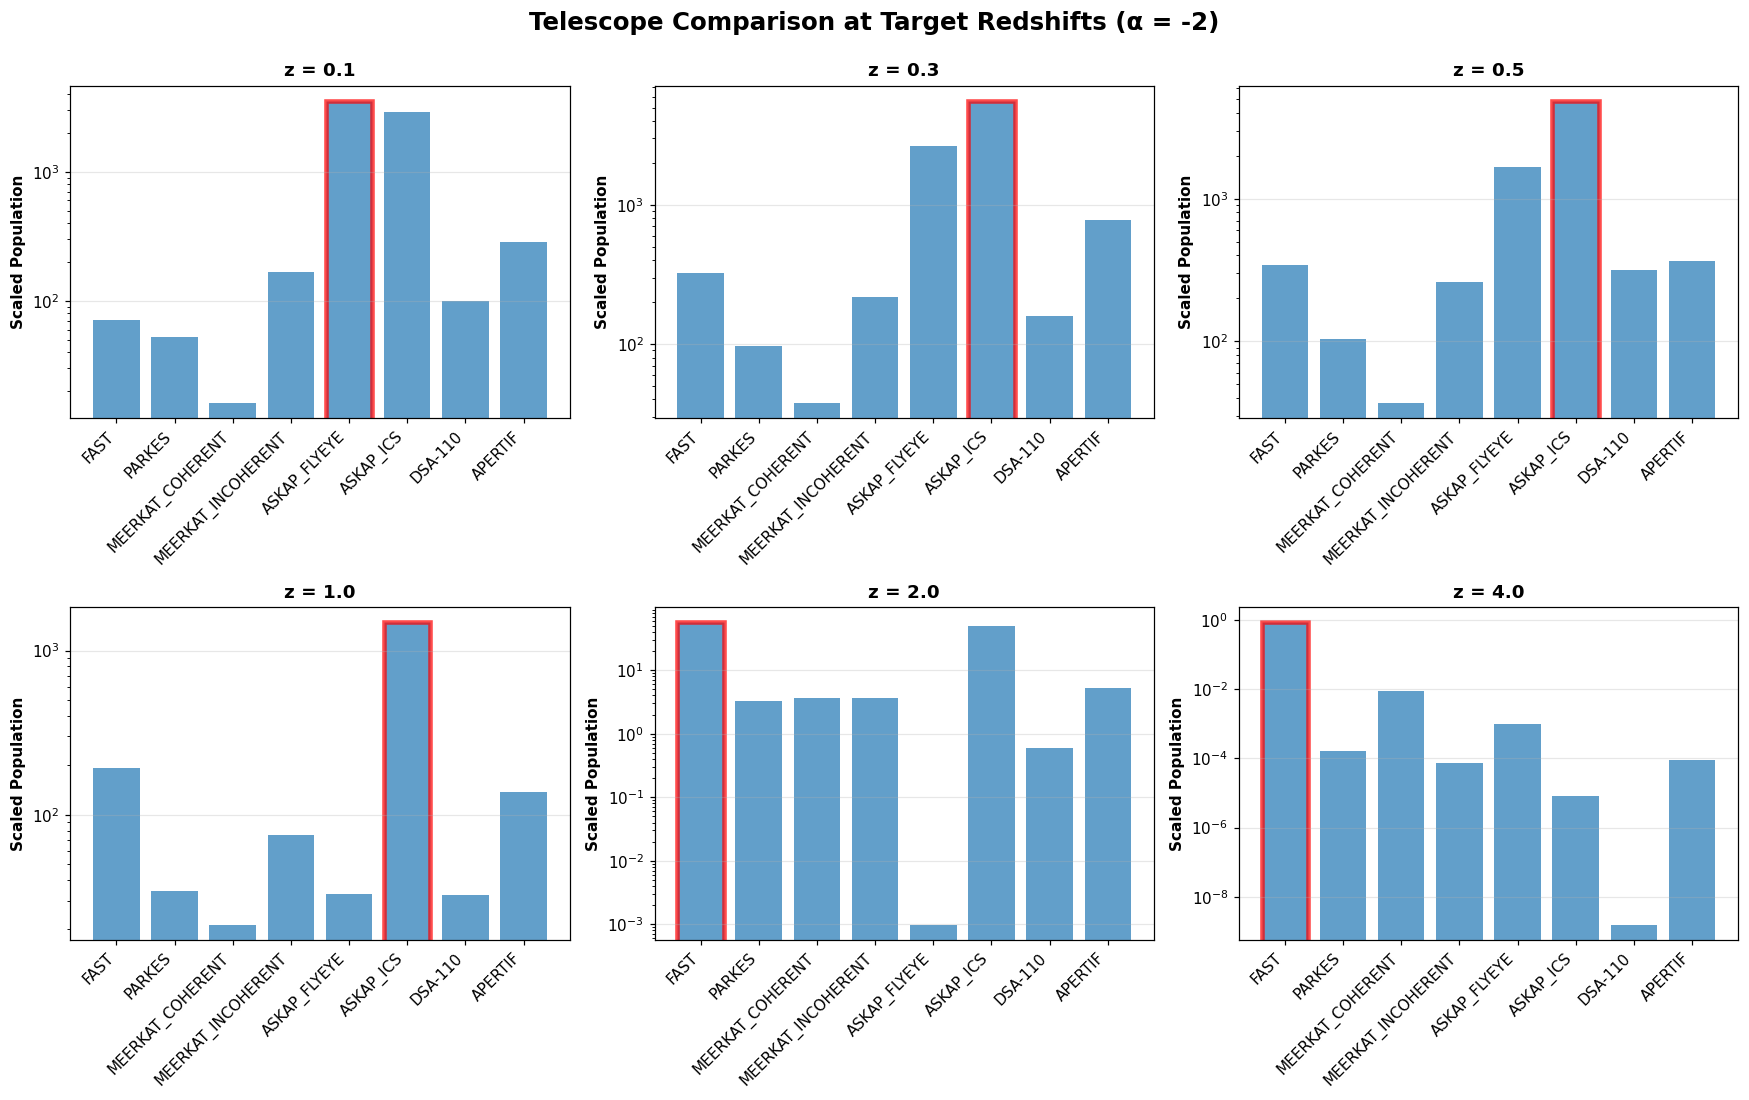


TELESCOPE RANKING AT EACH REDSHIFT (1=Best)
  z                     1                      2                  3                          4                          5                          6               7                       8
0.1 ASKAP_FLYEYE (3547.2)     ASKAP_ICS (2879.8)    APERTIF (283.6) MEERKAT_INCOHERENT (167.7)             DSA-110 (99.7)                FAST (71.7)   PARKES (52.4) MEERKAT_COHERENT (16.1)
0.3    ASKAP_ICS (5592.3)  ASKAP_FLYEYE (2626.8)    APERTIF (784.4)               FAST (326.1) MEERKAT_INCOHERENT (219.2)            DSA-110 (159.6)   PARKES (96.1) MEERKAT_COHERENT (37.6)
0.5    ASKAP_ICS (4864.6)  ASKAP_FLYEYE (1670.1)    APERTIF (367.7)               FAST (342.6)            DSA-110 (317.7) MEERKAT_INCOHERENT (258.5)  PARKES (103.6) MEERKAT_COHERENT (36.7)
1.0    ASKAP_ICS (1487.6)           FAST (191.3)    APERTIF (136.8)  MEERKAT_INCOHERENT (75.2)              PARKES (34.1)        ASKAP_FLYEYE (32.8)  DSA-110 (32.6) MEERKAT_COHERENT (21.4)
2.0       

In [15]:

# ============================================================================
# BAR CHART COMPARISON AT EACH REDSHIFT (SINGLE COLOR FOR ALL BARS)
# ============================================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10), dpi=110)
axes = axes.flatten()

# Add main title with alpha value at the top
fig.suptitle(f'Telescope Comparison at Target Redshifts (α = {ALPHA_TO_COMPARE})', 
             fontsize=16, fontweight='bold', y=0.995)

# Single color for all bars
bar_color = 'tab:blue'  # Nice blue color

for idx, target_z in enumerate(TARGET_REDSHIFTS):
    ax = axes[idx]
    
    # Get populations for this redshift
    populations = []
    labels = []
    for telescope in TELESCOPES:
        if telescope in data_dict:
            row_data = df_comparison[df_comparison['z'] == target_z].iloc[0]
            populations.append(row_data[telescope])
            labels.append(telescope.upper())
    
    # Bar chart with same color for all bars
    bars = ax.bar(range(len(labels)), populations, color=bar_color, alpha = 0.7)
    
    # Find and highlight the best telescope
    best_idx = np.argmax(populations)
    bars[best_idx].set_edgecolor('red')
    bars[best_idx].set_linewidth(3)
    
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_ylabel('Scaled Population', fontweight='bold')
    ax.set_title(f'z = {target_z}', fontweight='bold', fontsize=12)
    ax.grid(True, axis='y', alpha=0.3)
    ax.set_yscale('log')

plt.tight_layout()
# plt.savefig(f"population_comparison_specific_z_alpha{ALPHA_TO_COMPARE}.png", dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# RANKING TABLE
# ============================================================================
print("\n" + "="*100)
print("TELESCOPE RANKING AT EACH REDSHIFT (1=Best)")
print("="*100)

ranking_data = []
for target_z in TARGET_REDSHIFTS:
    row = {'z': target_z}
    row_data = df_comparison[df_comparison['z'] == target_z].iloc[0]
    
    # Sort telescopes by population
    pop_dict = {tel: row_data[tel] for tel in TELESCOPES if tel in data_dict}
    sorted_tel = sorted(pop_dict.items(), key=lambda x: x[1], reverse=True)
    
    for rank, (tel, pop) in enumerate(sorted_tel, 1):
        row[f'{rank}'] = f"{tel.upper()} ({pop:.1f})"
    
    ranking_data.append(row)

df_ranking = pd.DataFrame(ranking_data)
print(df_ranking.to_string(index=False))

fast                : Total population =     43,590.9
parkes              : Total population =     10,383.1
meerkat_coherent    : Total population =      4,688.8
meerkat_incoherent  : Total population =     25,162.5
askap_flyeye        : Total population =    212,803.8
askap_ics           : Total population =    411,378.7
dsa-110             : Total population =     15,665.1
apertif             : Total population =     41,098.2


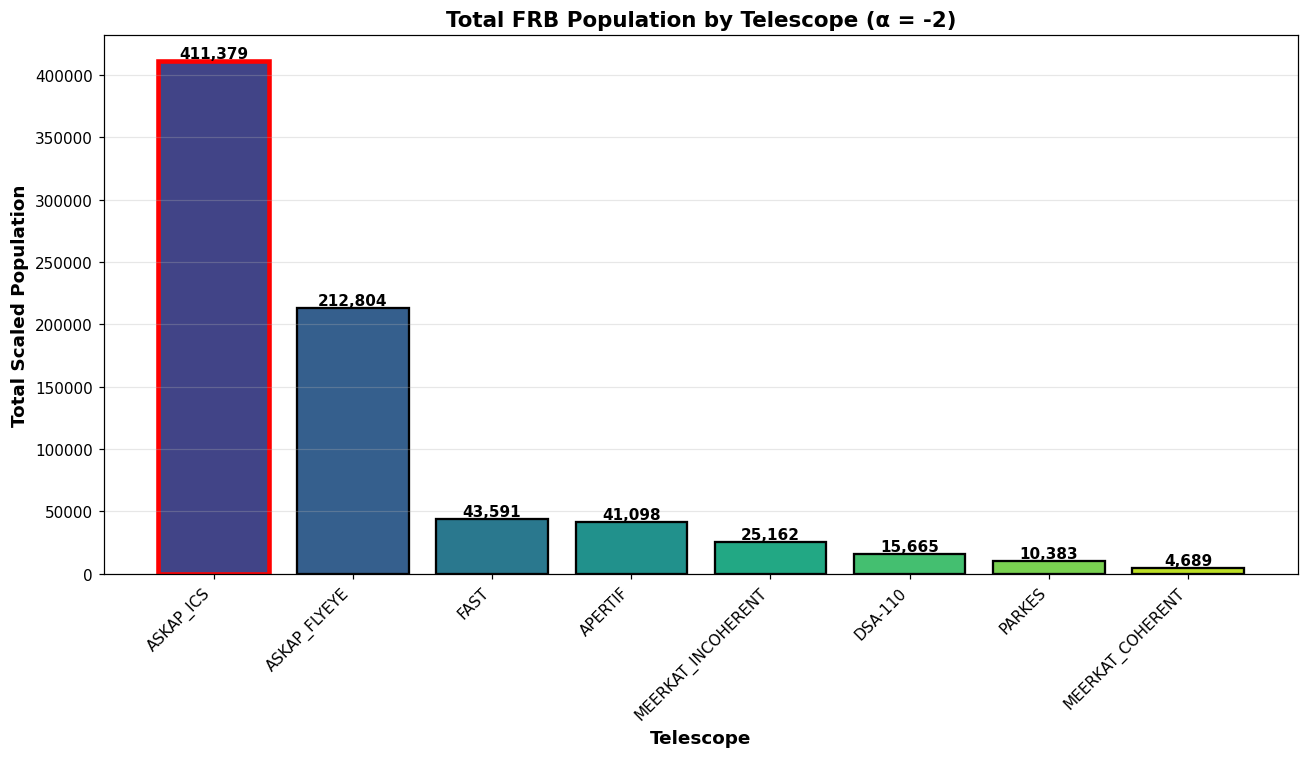


TELESCOPE RANKING BY TOTAL SCALED POPULATION
 Rank          Telescope Total_Population Percentage
    1          ASKAP_ICS        411,378.7      53.8%
    2       ASKAP_FLYEYE        212,803.8      27.8%
    3               FAST         43,590.9       5.7%
    4            APERTIF         41,098.2       5.4%
    5 MEERKAT_INCOHERENT         25,162.5       3.3%
    6            DSA-110         15,665.1       2.0%
    7             PARKES         10,383.1       1.4%
    8   MEERKAT_COHERENT          4,688.8       0.6%

Best Telescope: ASKAP_ICS with 411,378.7 FRBs
Worst Telescope: MEERKAT_COHERENT with 4,688.8 FRBs
Ratio (Best/Worst): 87.74x


In [16]:
# ============================================================================
# PLOT TOTAL SCALED POPULATION ACROSS ALL TELESCOPES
# ============================================================================

# Load all telescope data
total_populations = {}

for telescope in TELESCOPES:
    filename = f"DM_{telescope}_alpha{ALPHA_TO_COMPARE}_scaled.csv"
    filepath = os.path.join(RESULTS_DIR, filename)
    
    if os.path.exists(filepath):
        df = pd.read_csv(filepath)
        total_pop = df['n_total_population_scaled'].sum()
        total_populations[telescope] = total_pop
        print(f"{telescope:20s}: Total population = {total_pop:12,.1f}")
    else:
        print(f"✗ Not found: {filename}")

# Sort by total population (largest to smallest)
sorted_telescopes = sorted(total_populations.items(), key=lambda x: x[1], reverse=True)
tel_names = [t[0].upper() for t in sorted_telescopes]
tel_pops = [t[1] for t in sorted_telescopes]

# ============================================================================
# BAR CHART
# ============================================================================
fig, ax = plt.subplots(figsize=(12, 7), dpi=110)

# Create bars with color gradient
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(tel_names)))
bars = ax.bar(tel_names, tel_pops, color=colors, edgecolor='black', linewidth=1.5)

# Highlight the best (highest population)
bars[0].set_edgecolor('red')
bars[0].set_linewidth(3)

# Add value labels on top of bars
for bar, val in zip(bars, tel_pops):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:,.0f}',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_xlabel('Telescope', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Scaled Population', fontsize=12, fontweight='bold')
ax.set_title(f'Total FRB Population by Telescope (α = {ALPHA_TO_COMPARE})', 
             fontsize=14, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
if SAVE_PLOT:
    plt.savefig(f"total_population_by_telescope_alpha{ALPHA_TO_COMPARE}.png", dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# RANKING TABLE
# ============================================================================
print("\n" + "="*80)
print("TELESCOPE RANKING BY TOTAL SCALED POPULATION")
print("="*80)

ranking_df = pd.DataFrame({
    'Rank': range(1, len(sorted_telescopes) + 1),
    'Telescope': tel_names,
    'Total_Population': [f"{pop:,.1f}" for pop in tel_pops],
    'Percentage': [f"{(pop/sum(tel_pops))*100:.1f}%" for pop in tel_pops]
})

print(ranking_df.to_string(index=False))
print("="*80)

print(f"\nBest Telescope: {tel_names[0]} with {tel_pops[0]:,.1f} FRBs")
print(f"Worst Telescope: {tel_names[-1]} with {tel_pops[-1]:,.1f} FRBs")
print(f"Ratio (Best/Worst): {tel_pops[0]/tel_pops[-1]:.2f}x")